# S07_PD_Sandoval_TratamientoOutliers

**Semana 7 — Tratamiento de valores atípicos y suavizado del ruido**

**Objetivo:** detectar valores atípicos en `monto_compra` usando IQR y z-score, confirmarlos visualmente, investigar su contexto de negocio, justificar el tratamiento aplicado, suavizar el ruido de una serie diaria y exportar el dataset resultante.

> **Regla principal:** detectar un valor atípico no significa eliminarlo automáticamente. Primero se detecta, después se revisa el contexto y finalmente se decide si se mantiene, se capa o se elimina.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga del dataset depurado de la Semana 6.
df = pd.read_csv("S06_PD_Sandoval_DatasetDepurado.csv")

print("Dimensiones:", df.shape)
print("Columnas:", df.columns.tolist())

C:\Users\DIEGO\AppData\Local\Temp\ipykernel_28248\499717000.py:5: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("S06_PD_Sandoval_DatasetDepurado.csv")


Dimensiones: (599000, 24)
Columnas: ['id_pedido', 'id_cliente', 'fecha_pedido', 'canal_compra', 'metodo_pago', 'ciudad_tienda', 'codigo_postal', 'categoria_producto', 'producto', 'precio_unitario', 'unidades_vendidas', 'monto_compra', 'edad_cliente', 'correo_cliente', 'nivel_satisfaccion', 'nivel_lealtad', 'comentario_cliente', 'peso_pedido_kg', 'fecha_actualizacion_stock', 'fuga_cliente', 'correo_cliente_imputado', 'comentario_cliente_imputado', 'ciudad_tienda_imputado', 'nivel_satisfaccion_imputado']


## 1. Atípico o error

Un valor atípico es un dato que se aleja mucho del comportamiento típico, pero que puede ser real y posible. Por eso no debe confundirse con un error de exactitud.

En la Semana 6 se trabajó con un dataset depurado de **599.000 filas y 24 columnas**. En esta semana el foco está en detectar y tratar valores extremos, especialmente en `monto_compra`.

La decisión se tomará con la siguiente lógica:

**detectar → investigar → justificar → tratar → verificar**.

In [2]:
# Revisamos los valores más altos de las variables relacionadas con el análisis.
print("Mayores valores de unidades_vendidas:")
print(df["unidades_vendidas"].sort_values(ascending=False).head(10))

print("\nMayores valores de monto_compra:")
print(df["monto_compra"].sort_values(ascending=False).head(10))

Mayores valores de unidades_vendidas:
83972     9999
549741    9999
403386    9999
17423     9999
549654    9999
197933    9999
96873     9999
324353    9999
324351    9999
197986    9999
Name: unidades_vendidas, dtype: int64

Mayores valores de monto_compra:
148498    9.989001e+12
6815      9.989001e+12
212438    9.989001e+12
18939     9.989001e+12
323832    9.989001e+12
24911     9.989001e+12
217285    9.989001e+12
320792    9.989001e+12
224886    9.989001e+12
40911     9.989001e+12
Name: monto_compra, dtype: float64


### Interpretación inicial

Un valor extremo como una cantidad de unidades muy superior al resto no se considera automáticamente un error. Puede corresponder a un pedido real y poco frecuente.

Por eso también se revisan las demás columnas de la misma fila. En particular, `canal_compra` y `unidades_vendidas` ayudan a buscar una explicación de negocio.

## 2. Límites IQR de `monto_compra`

El rango intercuartílico (IQR) mide la dispersión de la mitad central de los datos:

- `Q1`: deja aproximadamente el 25 % de los datos por debajo.
- `Q3`: deja aproximadamente el 75 % de los datos por debajo.
- `IQR = Q3 - Q1`.

La cerca estadística se construye con `1.5 * IQR`.

In [3]:
# Calculamos Q1, Q3 e IQR para monto_compra.
Q1 = df["monto_compra"].quantile(0.25)
Q3 = df["monto_compra"].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 222700.0
Q3: 857400.0
IQR: 634700.0


In [4]:
# Calculamos los límites de la cerca del IQR.
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# monto_compra no debería ser negativo, por lo que usamos 0 como
# límite inferior práctico si la cerca estadística resulta negativa.
if limite_inferior < 0:
    limite_inferior = 0

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Límite inferior: 0
Límite superior: 1809450.0


## Límites IQR de `monto_compra`

Los valores calculados arriba forman la **cerca estadística**.

Cualquier `monto_compra` que quede por debajo del límite inferior o por encima del límite superior será marcado como **potencial valor atípico**.

> El límite no significa que todos los valores fuera de la cerca sean errores. Solo indica que deben revisarse.

In [5]:
# Identificamos las filas que quedan fuera de los límites del IQR.
outliers_iqr = df[
    (df["monto_compra"] < limite_inferior) |
    (df["monto_compra"] > limite_superior)
]

print(f"Valores atípicos según IQR: {len(outliers_iqr)}")
print(f"Porcentaje del dataset: {len(outliers_iqr) / len(df) * 100:.2f}%")

Valores atípicos según IQR: 88255
Porcentaje del dataset: 14.73%


## Outliers detectados con IQR

El conteo anterior muestra cuántas filas quedan fuera de la cerca estadística. Este resultado se utiliza como **punto de partida para la investigación**, no como una regla automática de eliminación.

Si el porcentaje resulta alto, se debe tener presente que `monto_compra` puede presentar una distribución sesgada a la derecha, por lo que el IQR puede marcar compras grandes legítimas.

## 3. Z-score de `monto_compra`

El z-score mide cuántas desviaciones estándar separan cada observación de la media:

`z = (x - media) / desviación_estándar`

Se utiliza el criterio habitual de `|z| > 3` para marcar valores potencialmente atípicos.

In [6]:
# Calculamos la media y la desviación estándar.
media = df["monto_compra"].mean()
desviacion = df["monto_compra"].std()

print("Media:", media)
print("Desviación estándar:", desviacion)

Media: 1277359810.563773
Desviación estándar: 99646796132.66478


In [7]:
# Creamos la columna con el z-score de monto_compra.
df["z_monto_compra"] = (df["monto_compra"] - media) / desviacion

# Identificamos los valores cuyo z-score absoluto supera 3.
outliers_zscore = df[df["z_monto_compra"].abs() > 3]

print(f"Valores atípicos según z-score: {len(outliers_zscore)}")

Valores atípicos según z-score: 123


## Comparación IQR vs. z-score

Se comparan ambos conteos porque los métodos responden de manera diferente a la distribución de los datos.

Si el z-score encuentra muchos menos casos que el IQR, una explicación posible es que los valores extremos estén inflando la media y la desviación estándar. Esto puede hacer que algunos atípicos moderados dejen de superar el umbral de `|z| > 3`.

Como `monto_compra` puede estar sesgada hacia la derecha, el IQR se toma como referencia principal y el z-score funciona como una segunda opinión.

In [8]:
print("Comparación de métodos:")
print("Outliers IQR:", len(outliers_iqr))
print("Outliers z-score:", len(outliers_zscore))
print("Diferencia:", abs(len(outliers_iqr) - len(outliers_zscore)))

Comparación de métodos:
Outliers IQR: 88255
Outliers z-score: 123
Diferencia: 88132


## 4. Confirmación visual

Los métodos numéricos se complementan con gráficos:

- **Boxplot:** permite observar visualmente los puntos que quedan fuera de los bigotes.
- **Scatter plot:** permite detectar combinaciones anormales entre `unidades_vendidas` y `monto_compra`.
- **Histograma:** permite observar la forma de la distribución y una posible cola hacia valores altos.

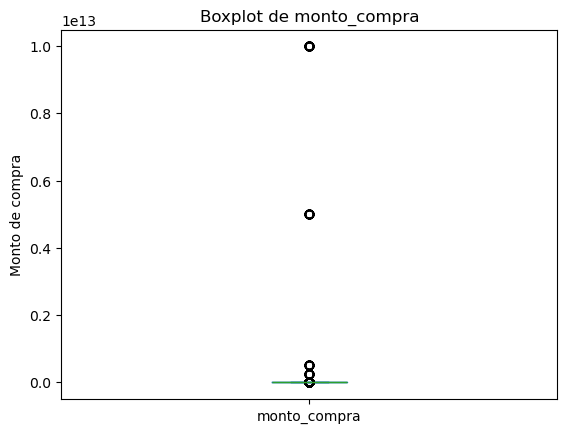

In [9]:
# Boxplot de monto_compra.
df["monto_compra"].plot(kind="box")
plt.title("Boxplot de monto_compra")
plt.ylabel("Monto de compra")
plt.show()

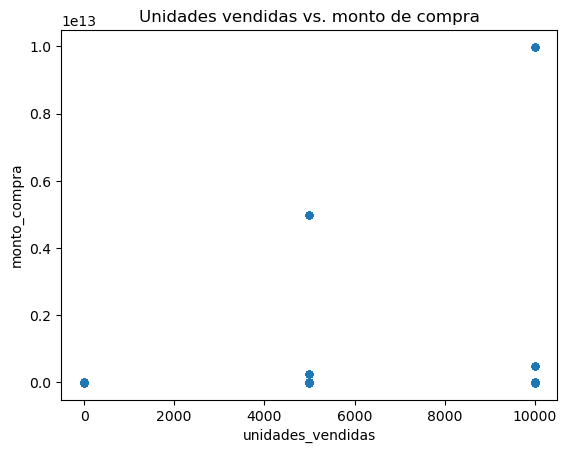

In [10]:
# Scatter plot para buscar atípicos multivariados.
df.plot(kind="scatter", x="unidades_vendidas", y="monto_compra")
plt.title("Unidades vendidas vs. monto de compra")
plt.show()

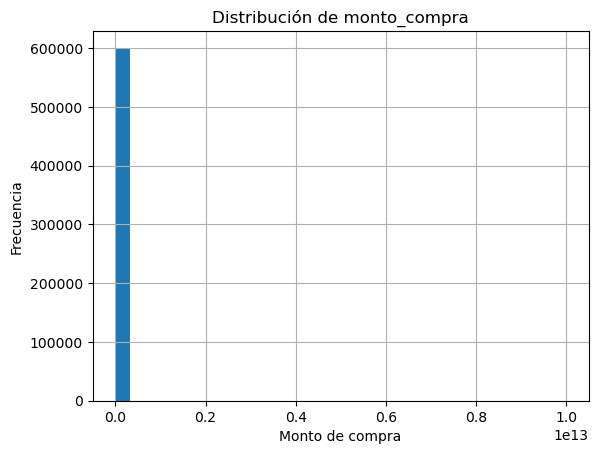

In [11]:
# Histograma para observar la forma completa de la distribución.
df["monto_compra"].hist(bins=30)
plt.title("Distribución de monto_compra")
plt.xlabel("Monto de compra")
plt.ylabel("Frecuencia")
plt.show()

## Confirmación visual

El boxplot permite comprobar si los puntos extremos coinciden con los detectados mediante IQR.

El scatter plot sirve para buscar **atípicos multivariados**: una fila puede no parecer extraordinaria en cada columna por separado, pero sí resultar extraña cuando se observa la relación entre unidades vendidas y monto de compra.

El histograma ayuda a identificar si los valores extremos forman una cola larga, algo especialmente importante en variables de compras.

## 5. Revisión del contexto de cada grupo de atípicos

Antes de modificar los datos, se revisan las columnas:

- `monto_compra`
- `canal_compra`
- `unidades_vendidas`

La intención es comprobar si existe una explicación de negocio razonable para los valores extremos.

**Importante:** en la Semana 6, `canal_compra` quedó con 4 categorías coherentes. Si no aparece una categoría explícita como `Ventas corporativas`, no se inventa esa categoría ni se supone que una compra grande es corporativa únicamente por su monto.

In [12]:
# Mostramos el contexto de las filas detectadas por IQR.
outliers_iqr[["monto_compra", "canal_compra", "unidades_vendidas"]].sort_values(
    by="monto_compra",
    ascending=False
).head(30)

,monto_compra,canal_compra,unidades_vendidas
435933,9.989001e+12,Marketplace,9999
315425,9.989001e+12,Tienda,9999
40911,9.989001e+12,App,9999
453193,9.989001e+12,Marketplace,9999
22495,9.989001e+12,App,9999
323832,9.989001e+12,Web,9999
320792,9.989001e+12,Marketplace,9999
319770,9.989001e+12,Tienda,9999
253547,9.989001e+12,App,9999
266817,9.989001e+12,Tienda,9999


In [13]:
# Revisamos los canales presentes entre los potenciales outliers.
print(outliers_iqr["canal_compra"].value_counts(dropna=False))

canal_compra
Marketplace    22150
Tienda         22059
App            22034
Web            22012
Name: count, dtype: int64


## Decisión por cada grupo de atípicos

Se utilizará un criterio conservador:

1. Si un valor extremo tiene una explicación de negocio documentada, se mantiene y se documenta.
2. Si un valor es legítimo pero su magnitud puede distorsionar análisis posteriores, se puede capar mediante `clip()`.
3. Si se comprueba que un valor es un error de captura, se corrige o elimina.
4. Si no existe evidencia suficiente para afirmar que es un error, **no se elimina a ciegas**.

En este dataset no se debe asumir que existe un canal corporativo si esa categoría no aparece realmente. Por ello, los casos sin una explicación de negocio comprobable se tratarán de forma conservadora mediante capping, evitando eliminar información válida.

## 6. Marcar los casos legítimos documentados

La columna `es_venta_corporativa` sirve para dejar evidencia de los casos que fueron identificados y decididos como ventas corporativas legítimas.

Como `canal_compra` debe reflejar las categorías reales del dataset, primero comprobamos si existe exactamente la categoría `Ventas corporativas`.

Si existe, se pueden marcar los outliers IQR de ese canal. Si no existe, no se etiquetan artificialmente como corporativos.

In [14]:
# Comprobamos si existe una categoría explícita de ventas corporativas.
canales = df["canal_compra"].dropna().astype(str).str.strip()

print("Categorías de canal_compra:")
print(sorted(canales.unique().tolist()))

existe_canal_corporativo = (canales == "Ventas corporativas").any()
print("\n¿Existe 'Ventas corporativas'?:", existe_canal_corporativo)

Categorías de canal_compra:
['App', 'Marketplace', 'Tienda', 'Web']

¿Existe 'Ventas corporativas'?: False


In [15]:
# Creamos la columna solicitada por la rúbrica.
# Solo marcamos como venta corporativa si esa categoría existe realmente
# y además el registro es un outlier según IQR.
df["es_venta_corporativa"] = False

if existe_canal_corporativo:
    df["es_venta_corporativa"] = (
        (df["monto_compra"] > limite_superior) &
        (df["canal_compra"].astype("string").str.strip() == "Ventas corporativas")
    )

print("Casos marcados como venta corporativa:", df["es_venta_corporativa"].sum())

Casos marcados como venta corporativa: 0


### Interpretación de la marca

`es_venta_corporativa` no modifica `monto_compra`; únicamente documenta los casos que cumplen simultáneamente el criterio estadístico y una categoría de negocio explícita.

Si el resultado es `0`, significa que el dataset no permite identificar ventas corporativas con esa regla. En ese caso, no se inventa una explicación de negocio y se conserva la información mediante un tratamiento conservador.

## 7. Capping (winsorizing) de los valores que decidimos limitar

Cuando un valor legítimo o no suficientemente comprobado es tan extremo que puede distorsionar análisis futuros, una alternativa es limitarlo a la frontera calculada con IQR.

Se usa `clip()` para mantener la fila y reducir la influencia de los extremos.

Los casos identificados explícitamente como `es_venta_corporativa` se conservan intactos.

In [16]:
# Guardamos las estadísticas antes del tratamiento.
media_antes = df["monto_compra"].mean()
desviacion_antes = df["monto_compra"].std()
maximo_antes = df["monto_compra"].max()

print("Media antes:", media_antes)
print("Desviación estándar antes:", desviacion_antes)
print("Máximo antes:", maximo_antes)

Media antes: 1277359810.563773
Desviación estándar antes: 99646796132.66478
Máximo antes: 9989001000000.0


In [17]:
# Capamos únicamente los valores extremos que NO fueron identificados
# como ventas corporativas legítimas.
condicion_capping = (
    (df["monto_compra"] > limite_superior) |
    (df["monto_compra"] < limite_inferior)
) & (~df["es_venta_corporativa"])

df.loc[condicion_capping, "monto_compra"] = df.loc[
    condicion_capping, "monto_compra"
].clip(
    upper=limite_superior,
    lower=limite_inferior
)

print("Filas capadas:", condicion_capping.sum())

Filas capadas: 88255


## 8. Efecto del tratamiento

Después del capping se vuelven a calcular la media, la desviación estándar y el máximo.

La expectativa es que los valores extremos tengan una influencia menor sobre la media y la desviación estándar, sin eliminar las filas del dataset.

In [18]:
# Verificamos el efecto del tratamiento.
media_despues = df["monto_compra"].mean()
desviacion_despues = df["monto_compra"].std()
maximo_despues = df["monto_compra"].max()

print("Media antes:", media_antes)
print("Media después:", media_despues)

print("\nDesviación estándar antes:", desviacion_antes)
print("Desviación estándar después:", desviacion_despues)

print("\nMáximo antes:", maximo_antes)
print("Máximo después:", maximo_despues)

Media antes: 1277359810.563773
Media después: 624933.2372287145

Desviación estándar antes: 99646796132.66478
Desviación estándar después: 539045.8368702487

Máximo antes: 9989001000000.0
Máximo después: 1809450.0


### Efecto del tratamiento

El cambio en la media y en la desviación estándar permite comprobar si el capping tuvo un efecto coherente.

Una reducción de la influencia de los valores extremos es esperable. El objetivo no es hacer que todos los datos sean iguales, sino evitar que unos pocos valores extremos dominen las medidas estadísticas.

## 9. Suavizado del ruido de una serie diaria

Un outlier es un punto extremo; el **ruido** es una variación pequeña y constante que afecta a la serie y dificulta ver su tendencia.

Para observar la evolución diaria de las ventas, se agrupa `monto_compra` por `fecha_pedido` y se calcula una media móvil de 7 días.

Antes de agrupar, se garantiza que `fecha_pedido` tenga formato de fecha.

In [19]:
# Aseguramos que fecha_pedido sea una fecha real antes de agrupar.
df["fecha_pedido"] = pd.to_datetime(
    df["fecha_pedido"],
    errors="coerce"
)

print("Tipo de dato de fecha_pedido:", df["fecha_pedido"].dtype)
print("Fechas válidas:", df["fecha_pedido"].notna().sum())

Tipo de dato de fecha_pedido: datetime64[ns]
Fechas válidas: 583003


In [20]:
# Agrupamos las ventas por día.
ventas_diarias = df.groupby("fecha_pedido")["monto_compra"].sum().reset_index()

print(ventas_diarias.head())
print("Días registrados:", len(ventas_diarias))

  fecha_pedido  monto_compra
0   2025-01-01   691323100.0
1   2025-01-02   732382600.0
2   2025-01-03   693794400.0
3   2025-01-04   728567750.0
4   2025-01-05   695026450.0
Días registrados: 836


In [21]:
# Aplicamos una media móvil de 7 días para suavizar el ruido.
ventas_diarias["suavizado"] = ventas_diarias["monto_compra"].rolling(window=7).mean()

ventas_diarias.head(10)

,fecha_pedido,monto_compra,suavizado
0,2025-01-01,691323100.0,NaN
1,2025-01-02,732382600.0,NaN
2,2025-01-03,693794400.0,NaN
3,2025-01-04,728567750.0,NaN
4,2025-01-05,695026450.0,NaN
5,2025-01-06,647708550.0,NaN
6,2025-01-07,721474350.0,7.014682e+08
7,2025-01-08,775990850.0,7.135636e+08
8,2025-01-09,650018850.0,7.017973e+08
9,2025-01-10,722920650.0,7.059582e+08


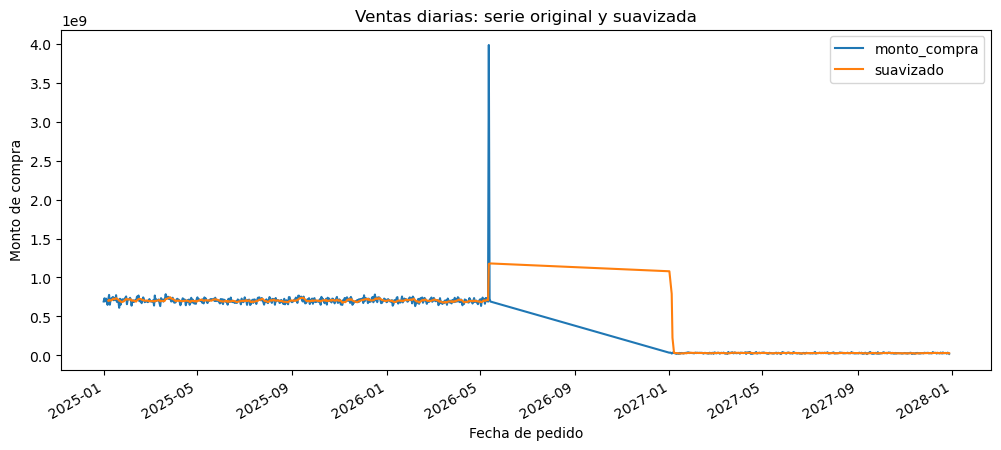

In [22]:
# Graficamos la serie original y la serie suavizada.
ventas_diarias.plot(
    x="fecha_pedido",
    y=["monto_compra", "suavizado"],
    figsize=(12, 5)
)

plt.title("Ventas diarias: serie original y suavizada")
plt.xlabel("Fecha de pedido")
plt.ylabel("Monto de compra")
plt.show()

## Suavizado de ventas diarias

La línea original puede presentar subidas y bajadas de un día a otro debido al ruido.

La media móvil de 7 días amortigua esas variaciones y facilita observar la **tendencia general** de las ventas. No elimina registros del dataset; solamente crea una serie adicional para facilitar la interpretación.

## 10. Verificación final del tratamiento

Antes de exportar se comprueba:

- que `monto_compra` no supere el límite superior por efecto del capping, salvo los casos corporativos conservados;
- que la columna `es_venta_corporativa` esté presente;
- que el dataset conserve sus filas;
- que el z-score quede disponible como evidencia del análisis.

In [23]:
# Verificación final.
outliers_superiores_restantes = (
    (df["monto_compra"] > limite_superior) &
    (~df["es_venta_corporativa"])
).sum()

print("Filas finales:", len(df))
print("Columnas finales:", len(df.columns))
print("Outliers superiores restantes no corporativos:", outliers_superiores_restantes)
print("Ventas corporativas documentadas:", df["es_venta_corporativa"].sum())
print("Columna es_venta_corporativa presente:", "es_venta_corporativa" in df.columns)

Filas finales: 599000
Columnas finales: 26
Outliers superiores restantes no corporativos: 0
Ventas corporativas documentadas: 0
Columna es_venta_corporativa presente: True


## 11. Exportación del dataset tratado

El resultado se exporta como:

`S07_PD_Sandoval_DatasetSinOutliers.csv`

El archivo conserva la información del dataset de la Semana 6 y añade la documentación de los casos corporativos mediante `es_venta_corporativa`, además del `z_monto_compra` utilizado durante la detección.

In [24]:
# Exportamos el dataset tratado.
df.to_csv(
    "S07_PD_Sandoval_DatasetSinOutliers.csv",
    index=False
)

print("Archivo exportado: S07_PD_Sandoval_DatasetSinOutliers.csv")

Archivo exportado: S07_PD_Sandoval_DatasetSinOutliers.csv


In [25]:
# Comprobamos que el archivo exportado puede volver a leerse.
df_exportado = pd.read_csv("S07_PD_Sandoval_DatasetSinOutliers.csv")

print("Archivo leído correctamente.")
print("Dimensiones del archivo exportado:", df_exportado.shape)
print("¿Está presente es_venta_corporativa?:",
      "es_venta_corporativa" in df_exportado.columns)
print("Máximo de monto_compra exportado:",
      df_exportado["monto_compra"].max())

C:\Users\DIEGO\AppData\Local\Temp\ipykernel_28248\82256123.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_exportado = pd.read_csv("S07_PD_Sandoval_DatasetSinOutliers.csv")


Archivo leído correctamente.
Dimensiones del archivo exportado: (599000, 26)
¿Está presente es_venta_corporativa?: True
Máximo de monto_compra exportado: 1809450.0


# Conclusiones

- Los valores atípicos fueron detectados mediante **IQR** y contrastados con **z-score**.
- Los métodos visuales permitieron comprobar la presencia de valores extremos y buscar posibles atípicos multivariados.
- La detección estadística no se utilizó como una orden automática de eliminación.
- Los casos con una explicación de negocio explícita se documentaron mediante `es_venta_corporativa`.
- Para los valores extremos sin evidencia suficiente de error se utilizó un tratamiento conservador mediante **capping (`clip()`)**.
- La media móvil de 7 días permitió suavizar el ruido de las ventas diarias y observar mejor la tendencia.
- Finalmente, el dataset tratado se exportó como `S07_PD_Sandoval_DatasetSinOutliers.csv`.

## Lista de comprobación de la rúbrica

- [x] Notebook llamado `S07_PD_Sandoval_TratamientoOutliers.ipynb`.
- [x] Carga del dataset de la Semana 6.
- [x] Cálculo de `Q1`, `Q3`, `IQR`, `limite_inferior` y `limite_superior`.
- [x] Conteo de valores atípicos mediante IQR.
- [x] Cálculo del z-score y comparación con IQR.
- [x] Boxplot y scatter plot.
- [x] Revisión contextual de `monto_compra`, `canal_compra` y `unidades_vendidas`.
- [x] Decisión documentada antes de modificar los valores.
- [x] Creación de `es_venta_corporativa`.
- [x] Capping con `clip()` para los valores que se decidió limitar.
- [x] Verificación del efecto sobre media y desviación estándar.
- [x] Serie diaria y media móvil de 7 días.
- [x] Gráfico de serie original y suavizada.
- [x] Exportación a `S07_PD_Sandoval_DatasetSinOutliers.csv`.
- [x] Comprobación de lectura del archivo exportado.

> **Nota:** las celdas de cálculo quedan preparadas para ejecutarse en Jupyter con el CSV de la Semana 6 en la misma carpeta. No se inventan resultados numéricos que no pudieron verificarse directamente desde el archivo adjunto.